In [11]:
import tensorflow as tf
from keras.datasets import mnist
from keras.models import Sequential
from keras.layers import Dense, Flatten, Conv2D, MaxPooling2D, Dropout
from keras.utils import to_categorical
import numpy as np
import matplotlib.pyplot as plt

In [3]:
(x_train, y_train), (x_test, y_test) = mnist.load_data()

x_train = x_train / 255.0
x_test = x_test / 255.0

y_train = y_train % 2
y_test = y_test % 2

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step


In [6]:
model = Sequential([
    Conv2D(32, kernel_size=(3,3), activation='relu', input_shape=(28,28,1)),
    MaxPooling2D(pool_size=(2,2)),
    Conv2D(64, kernel_size=(3,3), activation='relu'),
    MaxPooling2D(pool_size=(2,2)),
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(1, activation='sigmoid')
])

In [7]:
model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])

In [9]:
model.fit(x_train, y_train, epochs=5, batch_size=64, validation_split=0.1)

loss, accuracy = model.evaluate(x_test, y_test)
print(f"Test Accuracy: {accuracy:.4f}")

Epoch 1/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step - accuracy: 0.9584 - loss: 0.1109 - val_accuracy: 0.9858 - val_loss: 0.0412
Epoch 2/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - accuracy: 0.9850 - loss: 0.0447 - val_accuracy: 0.9917 - val_loss: 0.0272
Epoch 3/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - accuracy: 0.9892 - loss: 0.0314 - val_accuracy: 0.9910 - val_loss: 0.0265
Epoch 4/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - accuracy: 0.9919 - loss: 0.0244 - val_accuracy: 0.9923 - val_loss: 0.0247
Epoch 5/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step - accuracy: 0.9931 - loss: 0.0204 - val_accuracy: 0.9912 - val_loss: 0.0262
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9917 - loss: 0.0266
Test Accuracy: 0.9917


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step


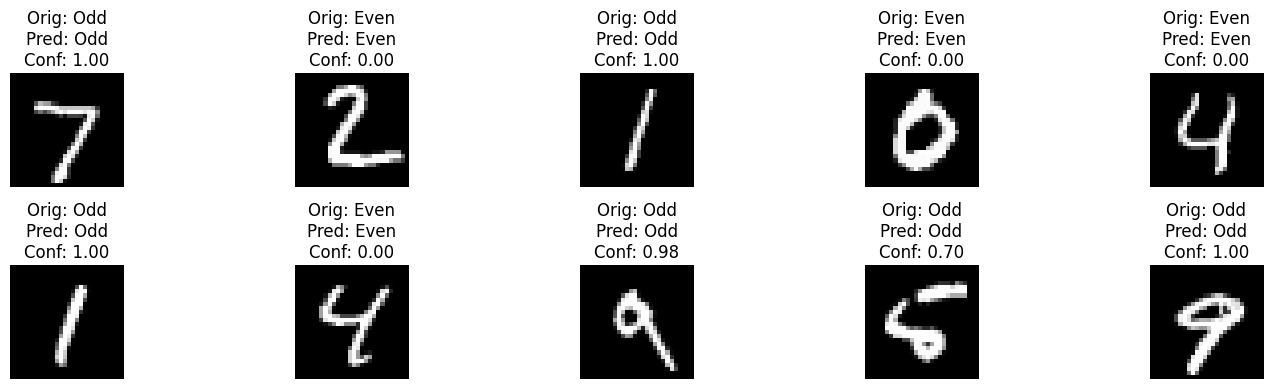

In [12]:
pred_probs = model.predict(x_test[:10])  # probability of class 1 (odd)
pred_labels = (pred_probs > 0.5).astype(int).flatten()
confidences = pred_probs.flatten()

plt.figure(figsize=(15,4))
for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(x_test[i].reshape(28,28), cmap='gray')
    plt.axis('off')
    plt.title(f"Orig: {'Odd' if y_test[i]==1 else 'Even'}\n"
              f"Pred: {'Odd' if pred_labels[i]==1 else 'Even'}\n"
              f"Conf: {confidences[i]:.2f}")
plt.tight_layout()
plt.show()